In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("Advertising.csv")
print(df.head())
print(df.shape)

   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9
(200, 5)


In [3]:
print(df.info())
print("\nNull values:\n", df.isnull().sum())
print("\nStatistics:\n", df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None

Null values:
 Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

Statistics:
        Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.500000  149.750000   22.9

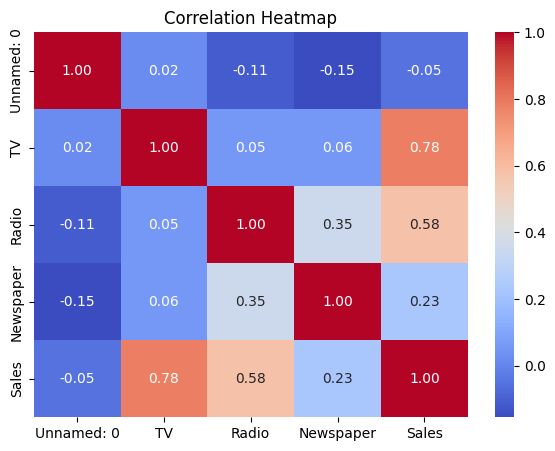

In [4]:
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

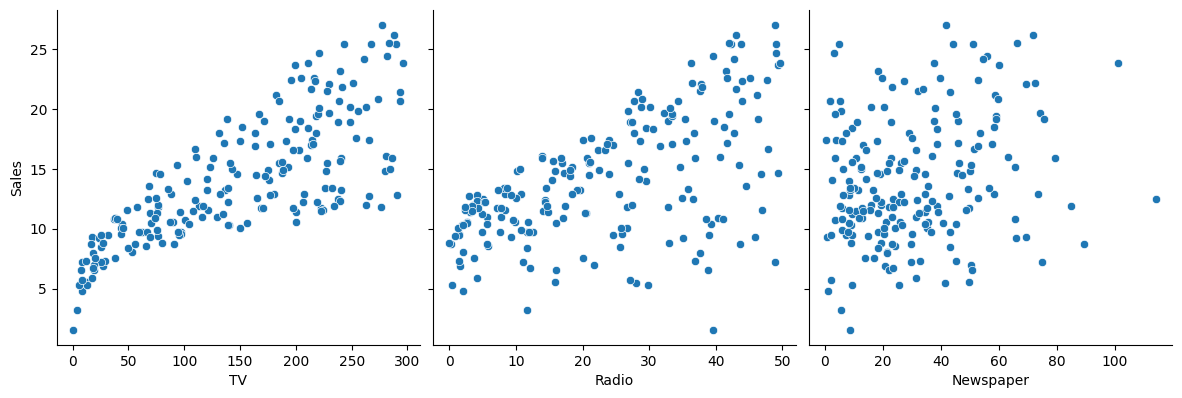

In [5]:
sns.pairplot(df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales', kind='scatter', height=4)
plt.show()

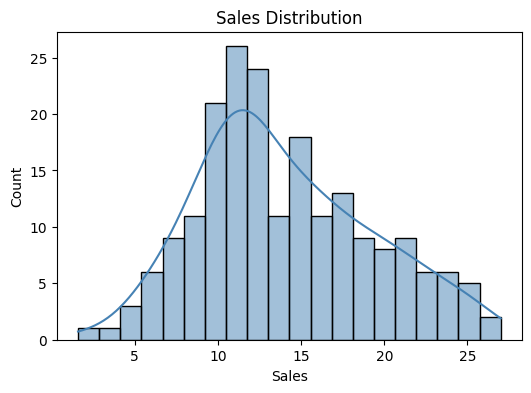

In [6]:
plt.figure(figsize=(6, 4))
sns.histplot(df['Sales'], bins=20, kde=True, color='steelblue')
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.show()

In [7]:
df['TV_Radio'] = df['TV'] * df['Radio']

X = df[['TV', 'Radio', 'Newspaper', 'TV_Radio']]
y = df['Sales']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (200, 4)
Target shape: (200,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 160, Test size: 40


In [9]:
lr = LinearRegression()
lr.fit(X_train, y_train)
print("Linear Regression trained.")

Linear Regression trained.


In [10]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest trained.")

Random Forest trained.


In [11]:
def evaluate(model, name):
    pred = model.predict(X_test)
    print(f"\n--- {name} ---")
    print(f"MAE  : {mean_absolute_error(y_test, pred):.3f}")
    print(f"RMSE : {np.sqrt(mean_squared_error(y_test, pred)):.3f}")
    print(f"R²   : {r2_score(y_test, pred):.3f}")
    return pred

lr_pred = evaluate(lr, "Linear Regression")
rf_pred = evaluate(rf, "Random Forest")


--- Linear Regression ---
MAE  : 0.672
RMSE : 0.902
R²   : 0.974

--- Random Forest ---
MAE  : 0.399
RMSE : 0.512
R²   : 0.992


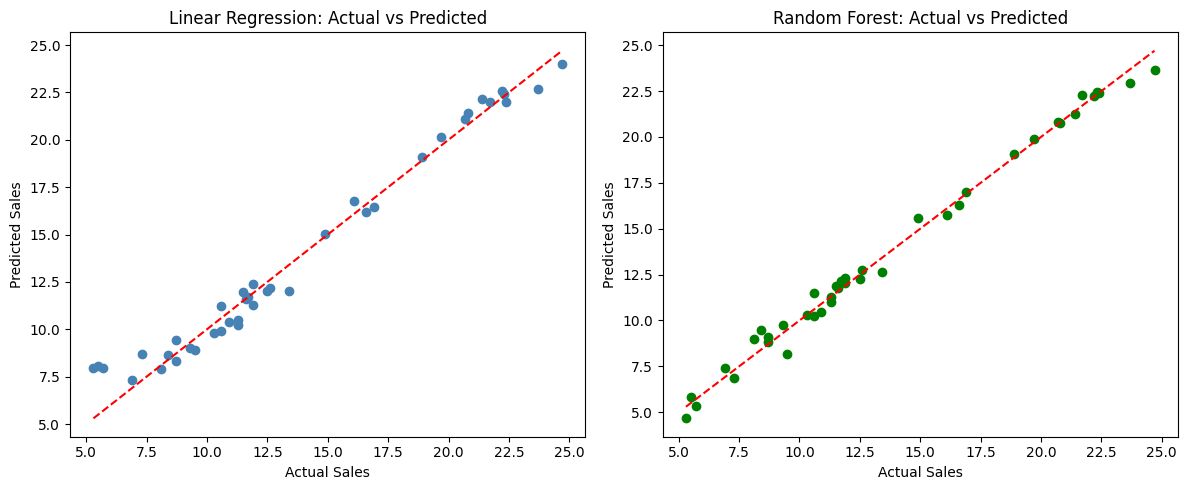

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, lr_pred, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.subplot(1, 2, 2)
plt.scatter(y_test, rf_pred, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.tight_layout()
plt.show()

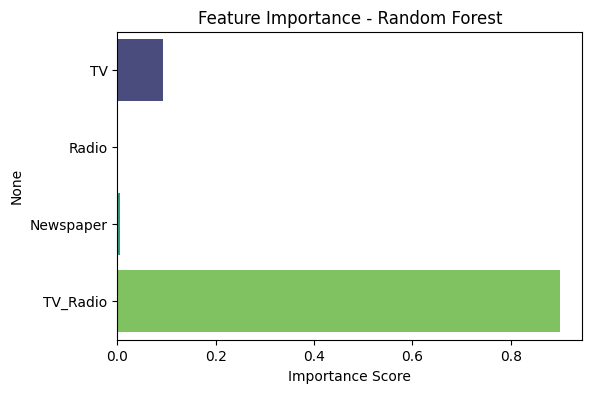

In [14]:
plt.figure(figsize=(6, 4))
sns.barplot(x=importances, y=feat_names, hue=feat_names, palette='viridis', legend=False)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.show()

In [15]:
print("Coefficients (Linear Regression):")
for name, coef in zip(X.columns, lr.coef_):
    print(f"  {name}: {coef:.4f}")
print(f"  Intercept: {lr.intercept_:.4f}")

Coefficients (Linear Regression):
  TV: 0.0196
  Radio: 0.0340
  Newspaper: 0.0019
  TV_Radio: 0.0010
  Intercept: 6.6499


Business Insights


In [16]:
print("""
BUSINESS INSIGHTS:
1. TV advertising has the highest impact on sales.
2. Radio has a moderate positive effect on sales.
3. Newspaper advertising contributes the least to sales.
4. Combined TV + Radio spend amplifies sales further.
5. Recommendation: Prioritize TV and Radio ad budgets
   for maximum sales return.
""")


BUSINESS INSIGHTS:
1. TV advertising has the highest impact on sales.
2. Radio has a moderate positive effect on sales.
3. Newspaper advertising contributes the least to sales.
4. Combined TV + Radio spend amplifies sales further.
5. Recommendation: Prioritize TV and Radio ad budgets
   for maximum sales return.

